# MovieLens 100k Pipeline — **Google Colab Edition**
### In-VM HDFS → Spark RDDs → DataFrames → Cassandra → read-back, + optional MongoDB / HBase

This notebook is the Colab-adapted twin of `movielens_pipeline.ipynb`. The **analytics
are identical**; only the environment layer is changed:

| Cluster notebook | This Colab notebook |
|---|---|
| The files are staged in **HDFS** (`hdfs:///movielens/`) | A **single-node HDFS is installed in-session**; the files are placed into `hdfs://localhost:9000/movielens/` via `hdfs dfs -put` — **Requirement 2 fully met** |
| Cassandra/HBase/Mongo are run on cluster hosts | All services are **installed in-session** inside the Colab VM |
| Helper `.py` files are shipped alongside | The helper modules are **written by the notebook** (`%%writefile`) |

> **Requirement 2 (load & parse into HDFS) is genuinely satisfied here.** In Setup 5 a
> real pseudo-distributed HDFS (NameNode + DataNode) is run inside the Colab VM and the
> three files are loaded into it; the data is then read from `hdfs://localhost:9000/...`.

> **Colab reality check.** The VM is temporary — every service and file is discarded
> when the runtime is reset, so the setup cells must be re-run each session. HDFS and
> Cassandra are fully supported here; **MongoDB is optional**; **HBase is skipped on
> Colab** (Thrift setup is impractical) and is left as documentation only.

**Run order.** *Run all* should be selected from the Runtime menu, or the cells run
top-to-bottom. A few minutes are required the first time while Hadoop and Cassandra are
downloaded; each download cell carries a timeout and shows progress, so it can simply be
re-run if a mirror stalls.

## Setup 1 — Install Java 11 (required by Spark 3.5 + Cassandra 4.1)

In [1]:
%%bash
apt-get -qq update > /dev/null
apt-get -qq install -y openjdk-11-jdk-headless > /dev/null
echo "Java installed:"; java -version 2>&1 | head -1

Java installed:
openjdk version "17.0.19" 2026-04-21


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## Setup 2 — Point the kernel at Java 11, install Python libs

In [2]:
import os
# Spark/Cassandra need JAVA_HOME; set it for THIS kernel so every later
# %%bash and PySpark call inherits it.
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]
print("JAVA_HOME =", os.environ["JAVA_HOME"])

JAVA_HOME = /usr/lib/jvm/java-11-openjdk-amd64


In [3]:
# PySpark brings its own Spark 3.5 distribution — no separate Spark download.
!pip install -q pyspark==3.5.1 pymongo happybase
print("pyspark + clients installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 98.0 kB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
pyspark + clients installed


## Setup 3 — Download MovieLens 100k into `/content`
The three files are first staged on local disk; they are then loaded **into HDFS** in
Setup 5.

In [4]:
%%bash
cd /content
if [ ! -d ml-100k ]; then
  wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
  unzip -q -o ml-100k.zip
fi
echo "Files in /content/ml-100k:"; ls -1 /content/ml-100k | grep -E '^u\.(user|data|item)$'

Files in /content/ml-100k:
u.data
u.item
u.user


## Setup 4 — Write the helper modules into the VM
In the cluster notebook, `genres.py` and `schemas.py` are imported from disk. Here they
are generated in `/content` so that the imports are resolved without anything being
uploaded.

In [5]:
%%writefile genres.py
GENRE_COLUMNS = [
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film_Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci_Fi", "Thriller", "War", "Western",
]
N_GENRES = len(GENRE_COLUMNS)
assert N_GENRES == 19, "MovieLens 100k must expose exactly 19 genre flags."


Writing genres.py


In [6]:
%%writefile schemas.py
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, LongType,
)
from genres import GENRE_COLUMNS

USER_SCHEMA = StructType([
    StructField("user_id",    IntegerType(), False),
    StructField("age",        IntegerType(), True),
    StructField("gender",     StringType(),  True),
    StructField("occupation", StringType(),  True),
    StructField("zip_code",   StringType(),  True),
])

RATING_SCHEMA = StructType([
    StructField("user_id",   IntegerType(), False),
    StructField("item_id",   IntegerType(), False),
    StructField("rating",    IntegerType(), False),
    StructField("timestamp", LongType(),    True),
])

def build_item_schema():
    fields = [
        StructField("item_id",      IntegerType(), False),
        StructField("title",        StringType(),  True),
        StructField("release_date", StringType(),  True),
        StructField("video_date",   StringType(),  True),
        StructField("imdb_url",     StringType(),  True),
    ]
    fields += [StructField(g, IntegerType(), True) for g in GENRE_COLUMNS]
    return StructType(fields)

ITEM_SCHEMA = build_item_schema()


Writing schemas.py


In [7]:
import sys
sys.path.insert(0, "/content")   # so `import genres, schemas` resolves
print("Helper modules ready.")

Helper modules ready.


## Setup 5 — Install single-node HDFS and load the files (**Requirement 2**)
No Hadoop is shipped with Colab, so Hadoop 3.3.6 is installed and a **pseudo-distributed
HDFS** (NameNode + DataNode) is run. On Colab the daemons are started *directly*
(`hdfs --daemon start`) so that **no SSH is required**. The three files are then placed
into HDFS with `hdfs dfs -put` — this is exactly *"load and parse the dataset files into
HDFS"*. The whole step is completed in roughly 1–2 minutes.

In [8]:
%%bash
cd /content
# Drop any partial/corrupt download (<500MB == it did not finish).
[ -f hadoop-3.3.6.tar.gz ] && [ $(stat -c%s hadoop-3.3.6.tar.gz) -lt 500000000 ] && rm -f hadoop-3.3.6.tar.gz
if [ ! -d hadoop-3.3.6 ]; then
  echo "Downloading Hadoop ~700MB (timeout + progress; re-run this cell to resume)..."
  # Fast current mirror first, fall back to the archive. --timeout makes a stalled
  # connection FAIL FAST instead of hanging forever (-q with no timeout was the bug).
  wget -c --timeout=30 --tries=3 --show-progress -q \
    https://dlcdn.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz \
    || wget -c --timeout=30 --tries=3 --show-progress -q \
    https://archive.apache.org/dist/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
  echo "Extracting..."; tar xzf hadoop-3.3.6.tar.gz
fi
echo "Hadoop ready:"; ls -d /content/hadoop-3.3.6

Extracting...
Hadoop ready:
/content/hadoop-3.3.6



     0K .......... .......... .......... .......... ..........  0% 4.89M 2m22s
    50K .......... .......... .......... .......... ..........  0% 18.9M 90s
   100K .......... .......... .......... .......... ..........  0% 9.24M 85s
   150K .......... .......... .......... .......... ..........  0% 18.1M 73s
   200K .......... .......... .......... .......... ..........  0% 73.9M 60s
   250K .......... .......... .......... .......... ..........  0% 13.6M 59s
   300K .......... .......... .......... .......... ..........  0% 43.7M 53s
   350K .......... .......... .......... .......... ..........  0% 44.0M 48s
   400K .......... .......... .......... .......... ..........  0% 31.2M 45s
   450K .......... .......... .......... .......... ..........  0% 86.5M 42s
   500K .......... .......... .......... .......... ..........  0%  307M 38s
   550K .......... .......... .......... .......... ..........  0% 16.4M 38s
   600K .......... .......... .......... .......... ..........  0%  104M 

In [9]:
import os
# Make hadoop binaries visible to this kernel AND to every later %%bash cell.
os.environ["HADOOP_HOME"] = "/content/hadoop-3.3.6"
os.environ["JAVA_HOME"]   = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] = (os.environ["HADOOP_HOME"] + "/bin:"
                      + os.environ["HADOOP_HOME"] + "/sbin:"
                      + os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"])
# Hadoop daemon scripts read JAVA_HOME from hadoop-env.sh as well:
with open("/content/hadoop-3.3.6/etc/hadoop/hadoop-env.sh", "a") as f:
    f.write("\nexport JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64\n")
print("HADOOP_HOME =", os.environ["HADOOP_HOME"])

HADOOP_HOME = /content/hadoop-3.3.6


In [10]:
%%bash
# Minimal pseudo-distributed config: NameNode at localhost:9000, replication 1.
cat > $HADOOP_HOME/etc/hadoop/core-site.xml <<'XML'
<configuration>
  <property><name>fs.defaultFS</name><value>hdfs://localhost:9000</value></property>
  <property><name>hadoop.tmp.dir</name><value>/content/hadoop-tmp</value></property>
</configuration>
XML
cat > $HADOOP_HOME/etc/hadoop/hdfs-site.xml <<'XML'
<configuration>
  <property><name>dfs.replication</name><value>1</value></property>
</configuration>
XML
echo "HDFS config written."

HDFS config written.


In [11]:
%%bash
# Format once, then start NameNode + DataNode directly (no SSH on Colab).
hdfs namenode -format -force -nonInteractive > /content/hdfs-format.log 2>&1
hdfs --daemon start namenode
hdfs --daemon start datanode
sleep 8
echo "--- running Java daemons ---"; jps
jps | grep -q NameNode && jps | grep -q DataNode \
  && echo "HDFS is UP" \
  || (echo "HDFS not up - format log tail:"; tail -25 /content/hdfs-format.log)

--- running Java daemons ---
3018 DataNode
3178 Jps
2958 NameNode
HDFS is UP


In [12]:
%%bash
# *** Requirement 2: load the three raw files INTO HDFS, then list them. ***
hdfs dfs -mkdir -p /movielens
hdfs dfs -put -f /content/ml-100k/u.user /movielens/
hdfs dfs -put -f /content/ml-100k/u.data /movielens/
hdfs dfs -put -f /content/ml-100k/u.item /movielens/
echo "---- HDFS /movielens listing ----"
hdfs dfs -ls -h /movielens

---- HDFS /movielens listing ----
Found 3 items
-rw-r--r--   1 root supergroup      1.9 M 2026-06-10 03:05 /movielens/u.data
-rw-r--r--   1 root supergroup    230.8 K 2026-06-10 03:05 /movielens/u.item
-rw-r--r--   1 root supergroup     22.1 K 2026-06-10 03:05 /movielens/u.user


## Setup 6 — Install & start Apache Cassandra 4.1 (hardened for Colab)
The usual cause of *"Cassandra not ready"* on Colab is that the container hostname is not
resolved, so Cassandra cannot be bound. **Loopback addresses are forced** in
`cassandra.yaml` and **the heap is capped**; the log is surfaced if startup still fails.

In [13]:
%%bash
cd /content
if [ ! -d apache-cassandra-4.1.4 ]; then
  wget -q https://archive.apache.org/dist/cassandra/4.1.4/apache-cassandra-4.1.4-bin.tar.gz
  tar xzf apache-cassandra-4.1.4-bin.tar.gz
fi
CONF=/content/apache-cassandra-4.1.4/conf
# Bind to loopback -> fixes hostname-resolution startup failures on Colab.
sed -i 's/^listen_address:.*/listen_address: 127.0.0.1/' $CONF/cassandra.yaml
sed -i 's/^rpc_address:.*/rpc_address: 127.0.0.1/'       $CONF/cassandra.yaml
# Cap the heap so Cassandra can't starve the VM (default would grab ~3GB+).
grep -q "MAX_HEAP_SIZE=" $CONF/cassandra-env.sh || cat >> $CONF/cassandra-env.sh <<'EOF'
MAX_HEAP_SIZE="2G"
HEAP_NEWSIZE="400M"
EOF
echo "Cassandra configured (loopback + capped heap)."

Cassandra configured (loopback + capped heap).


In [14]:
%%bash
export JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64
# -R lets Cassandra run as root (Colab); log to a file we can inspect.
nohup /content/apache-cassandra-4.1.4/bin/cassandra -R > /content/cassandra.log 2>&1 &
echo "Cassandra launching... (poll cell below waits for it)"

Cassandra launching... (poll cell below waits for it)


In [15]:
# Confirm Cassandra is accepting CQL, using the native Python driver.
# (We avoid the bundled `cqlsh`, which crashes on Colab's newer Python via six.moves.)
import subprocess, sys, time
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "cassandra-driver"])
from cassandra.cluster import Cluster
from cassandra import OperationTimedOut
up = False
for i in range(72):                       # up to ~6 minutes
    try:
        s = Cluster(['127.0.0.1'], port=9042, connect_timeout=10).connect()
        print("Cassandra is UP:", s.execute("SELECT release_version FROM system.local").one()[0]); up = True; break
    except Exception as e:
        print(f"  waiting... ({(i+1)*5}s)  [{type(e).__name__}]")
        time.sleep(5)
if not up:
    print("\n*** Cassandra still not ready - last 40 log lines ***\n")
    try: print("".join(open("/content/cassandra.log").readlines()[-40:]))
    except FileNotFoundError: print("(no cassandra.log - did the launch cell run?)")

Traceback (most recent call last):
  File "cassandra/cluster.py", line 3670, in cassandra.cluster.ControlConnection._reconnect_internal
  File "cassandra/cluster.py", line 3692, in cassandra.cluster.ControlConnection._try_connect
  File "cassandra/cluster.py", line 1671, in cassandra.cluster.Cluster.connection_factory
  File "cassandra/connection.py", line 858, in cassandra.connection.Connection.factory
  File "/usr/local/lib/python3.12/dist-packages/cassandra/io/libevreactor.py", line 269, in __init__
    self._connect_socket()
  File "cassandra/connection.py", line 963, in cassandra.connection.Connection._connect_socket
ConnectionRefusedError: [Errno 111] Tried connecting to [('127.0.0.1', 9042)]. Last error: Connection refused
ERROR:cassandra.cluster:Control connection failed to connect, shutting down Cluster:
Traceback (most recent call last):
  File "cassandra/cluster.py", line 1741, in cassandra.cluster.Cluster.connect
  File "cassandra/cluster.py", line 3636, in cassandra.cluste

  waiting... (5s)  [NoHostAvailable]


Traceback (most recent call last):
  File "cassandra/cluster.py", line 3670, in cassandra.cluster.ControlConnection._reconnect_internal
  File "cassandra/cluster.py", line 3692, in cassandra.cluster.ControlConnection._try_connect
  File "cassandra/cluster.py", line 1671, in cassandra.cluster.Cluster.connection_factory
  File "cassandra/connection.py", line 858, in cassandra.connection.Connection.factory
  File "/usr/local/lib/python3.12/dist-packages/cassandra/io/libevreactor.py", line 269, in __init__
    self._connect_socket()
  File "cassandra/connection.py", line 963, in cassandra.connection.Connection._connect_socket
ConnectionRefusedError: [Errno 111] Tried connecting to [('127.0.0.1', 9042)]. Last error: Connection refused
ERROR:cassandra.cluster:Control connection failed to connect, shutting down Cluster:
Traceback (most recent call last):
  File "cassandra/cluster.py", line 1741, in cassandra.cluster.Cluster.connect
  File "cassandra/cluster.py", line 3636, in cassandra.cluste

  waiting... (10s)  [NoHostAvailable]


Traceback (most recent call last):
  File "cassandra/cluster.py", line 3670, in cassandra.cluster.ControlConnection._reconnect_internal
  File "cassandra/cluster.py", line 3692, in cassandra.cluster.ControlConnection._try_connect
  File "cassandra/cluster.py", line 1671, in cassandra.cluster.Cluster.connection_factory
  File "cassandra/connection.py", line 858, in cassandra.connection.Connection.factory
  File "/usr/local/lib/python3.12/dist-packages/cassandra/io/libevreactor.py", line 269, in __init__
    self._connect_socket()
  File "cassandra/connection.py", line 963, in cassandra.connection.Connection._connect_socket
ConnectionRefusedError: [Errno 111] Tried connecting to [('127.0.0.1', 9042)]. Last error: Connection refused
ERROR:cassandra.cluster:Control connection failed to connect, shutting down Cluster:
Traceback (most recent call last):
  File "cassandra/cluster.py", line 1741, in cassandra.cluster.Cluster.connect
  File "cassandra/cluster.py", line 3636, in cassandra.cluste

...

Traceback (most recent call last):
  File "cassandra/cluster.py", line 3670, in cassandra.cluster.ControlConnection._reconnect_internal
  File "cassandra/cluster.py", line 3692, in cassandra.cluster.ControlConnection._try_connect
  File "cassandra/cluster.py", line 1671, in cassandra.cluster.Cluster.connection_factory
  File "cassandra/connection.py", line 858, in cassandra.connection.Connection.factory
  File "/usr/local/lib/python3.12/dist-packages/cassandra/io/libevreactor.py", line 269, in __init__
    self._connect_socket()
  File "cassandra/connection.py", line 963, in cassandra.connection.Connection._connect_socket
ConnectionRefusedError: [Errno 111] Tried connecting to [('127.0.0.1', 9042)]. Last error: Connection refused
ERROR:cassandra.cluster:Control connection failed to connect, shutting down Cluster:
Traceback (most recent call last):
  File "cassandra/cluster.py", line 1741, in cassandra.cluster.Cluster.connect
  File "cassandra/cluster.py", line 3636, in cassandra.cluste

  waiting... (50s)  [NoHostAvailable]


Traceback (most recent call last):
  File "cassandra/cluster.py", line 3670, in cassandra.cluster.ControlConnection._reconnect_internal
  File "cassandra/cluster.py", line 3692, in cassandra.cluster.ControlConnection._try_connect
  File "cassandra/cluster.py", line 1671, in cassandra.cluster.Cluster.connection_factory
  File "cassandra/connection.py", line 858, in cassandra.connection.Connection.factory
  File "/usr/local/lib/python3.12/dist-packages/cassandra/io/libevreactor.py", line 269, in __init__
    self._connect_socket()
  File "cassandra/connection.py", line 963, in cassandra.connection.Connection._connect_socket
ConnectionRefusedError: [Errno 111] Tried connecting to [('127.0.0.1', 9042)]. Last error: Connection refused
ERROR:cassandra.cluster:Control connection failed to connect, shutting down Cluster:
Traceback (most recent call last):
  File "cassandra/cluster.py", line 1741, in cassandra.cluster.Cluster.connect
  File "cassandra/cluster.py", line 3636, in cassandra.cluste

  waiting... (55s)  [NoHostAvailable]


Cassandra is UP: 4.1.4


---
## 1. Imports & SparkSession (Requirement 1)
This section is identical to the cluster notebook — the Cassandra/Mongo connectors are
pulled from Maven Central at startup (internet is available on Colab).

In [16]:
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, LongType, DoubleType,
)
from genres import GENRE_COLUMNS, N_GENRES
from schemas import USER_SCHEMA, RATING_SCHEMA, ITEM_SCHEMA

CASSANDRA_CONNECTOR = "com.datastax.spark:spark-cassandra-connector_2.12:3.5.0"
MONGO_CONNECTOR     = "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0"

spark = (
    SparkSession.builder
        .appName("MovieLens100k-Colab")
        .master("local[*]")
        .config("spark.jars.packages", f"{CASSANDRA_CONNECTOR},{MONGO_CONNECTOR}")
        .config("spark.sql.extensions",
                "com.datastax.spark.connector.CassandraSparkExtensions")
        .config("spark.cassandra.connection.host", "127.0.0.1")
        .config("spark.cassandra.connection.port", "9042")
        .config("spark.sql.catalog.cass",
                "com.datastax.spark.connector.datasource.CassandraCatalog")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 3.5.1


## 2. HDFS paths (Requirement 2)
The data is read straight from the HDFS that was populated in Setup 5 — the same `hdfs://`
URIs that would be used on a real cluster (the full `localhost:9000` authority is given so
that Spark's bundled Hadoop client is connected to the NameNode).

In [17]:
BASE        = "hdfs://localhost:9000/movielens"
USER_PATH   = f"{BASE}/u.user"
RATING_PATH = f"{BASE}/u.data"
ITEM_PATH   = f"{BASE}/u.item"
print("Reading from HDFS:", USER_PATH, RATING_PATH, ITEM_PATH, sep="\n  ")

Reading from HDFS:
  hdfs://localhost:9000/movielens/u.user
  hdfs://localhost:9000/movielens/u.data
  hdfs://localhost:9000/movielens/u.item


## 3. Create RDDs from the HDFS files (Requirement 3)
`u.user` and `u.data` are ASCII and are read with `textFile`. `u.item` is **latin-1**, so
its raw **bytes are pulled from HDFS** with `binaryFiles` and decoded explicitly; in this
way the accented film titles are kept intact (with plain `textFile` they would be assumed
to be UTF-8 and corrupted).

In [18]:
sc = spark.sparkContext

user_lines   = sc.textFile(USER_PATH)
rating_lines = sc.textFile(RATING_PATH)

# latin-1 safe read of u.item FROM HDFS: get the file's bytes, decode, parallelize.
item_bytes = sc.binaryFiles(ITEM_PATH).values().first()       # bytes of the single file
item_lines_local = [ln for ln in item_bytes.decode("latin-1").splitlines() if ln.strip()]
item_lines = sc.parallelize(item_lines_local)

print("u.user lines :", user_lines.count())
print("u.data lines :", rating_lines.count())
print("u.item lines :", item_lines.count())

u.user lines : 943
u.data lines : 100000
u.item lines : 1682


In [19]:
def parse_user(line):
    p = line.split("|")
    return (int(p[0]), int(p[1]), p[2], p[3], p[4])

def parse_rating(line):
    p = line.split("\t")
    return (int(p[0]), int(p[1]), int(p[2]), int(p[3]))

def parse_item(line):
    p = line.split("|")
    item_id      = int(p[0]); title = p[1]
    release_date = p[2] or None
    video_date   = p[3] or None
    imdb_url     = p[4] or None
    genres       = [int(x) for x in p[5:5 + N_GENRES]]
    return (item_id, title, release_date, video_date, imdb_url, *genres)

user_rdd   = user_lines.map(parse_user)
rating_rdd = rating_lines.map(parse_rating)
item_rdd   = item_lines.map(parse_item)

print("Sample item:", item_rdd.first()[:2], "... (+19 genre flags)")

Sample item: (1, 'Toy Story (1995)') ... (+19 genre flags)


## 4. RDDs → typed DataFrames (Requirement 4)

In [20]:
users_df   = spark.createDataFrame(user_rdd,   schema=USER_SCHEMA)
ratings_df = spark.createDataFrame(rating_rdd, schema=RATING_SCHEMA)
items_df   = spark.createDataFrame(item_rdd,   schema=ITEM_SCHEMA)
users_df.printSchema()
items_df.select("item_id","title","release_date",*GENRE_COLUMNS[:3]).show(3, truncate=False)

root
 |-- user_id: integer (nullable = false)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- zip_code: string (nullable = true)

+-------+-----------------+------------+-------+------+---------+
|item_id|title            |release_date|unknown|Action|Adventure|
+-------+-----------------+------------+-------+------+---------+
|1      |Toy Story (1995) |01-Jan-1995 |0      |0     |0        |
|2      |GoldenEye (1995) |01-Jan-1995 |0      |1     |1        |
|3      |Four Rooms (1995)|01-Jan-1995 |0      |0     |0        |
+-------+-----------------+------------+-------+------+---------+
only showing top 3 rows



## 5. Cleaning & preprocessing (Requirement 5)
The types are cast via the schemas, the latin-1 fix is applied (above), null/range
validation is performed, and `(user_id, item_id)` pairs are de-duplicated with the newest
rating kept.

In [21]:
users_clean = (
    users_df.dropna(subset=["user_id"])
        .filter((F.col("age").between(5,120)) | F.col("age").isNull())
        .withColumn("gender", F.upper(F.trim("gender")))
        .withColumn("occupation", F.lower(F.trim("occupation")))
)
ratings_valid = (
    ratings_df.dropna(subset=["user_id","item_id","rating"])
        .filter(F.col("rating").between(1,5))
)
w = Window.partitionBy("user_id","item_id").orderBy(F.col("timestamp").desc())
ratings_clean = (
    ratings_valid.withColumn("rn", F.row_number().over(w))
        .filter(F.col("rn")==1).drop("rn")
)
items_clean = (
    items_df.filter(F.col("title").isNotNull() & (F.trim("title")!=""))
        .replace("", None, subset=["release_date","video_date","imdb_url"])
)
print("users  :", users_df.count(),  "->", users_clean.count())
print("ratings:", ratings_df.count(),"->", ratings_clean.count())
print("items  :", items_df.count(),  "->", items_clean.count())
for d in (users_clean, ratings_clean, items_clean): d.cache()

users_clean.createOrReplaceTempView("users")
ratings_clean.createOrReplaceTempView("ratings")
items_clean.createOrReplaceTempView("items")

users  : 943 -> 943
ratings: 100000 -> 100000
items  : 1682 -> 1682


## Task (i) — Average rating per movie (Requirement 6)

In [22]:
avg_rating_df = spark.sql('''
    SELECT r.item_id, i.title,
           ROUND(AVG(r.rating),3) AS avg_rating,
           COUNT(*) AS num_ratings
    FROM ratings r JOIN items i ON r.item_id = i.item_id
    GROUP BY r.item_id, i.title
    ORDER BY r.item_id
''')
avg_rating_df.show(10, truncate=False)
print("Rated movies:", avg_rating_df.count())

+-------+----------------------------------------------------+----------+-----------+
|item_id|title                                               |avg_rating|num_ratings|
+-------+----------------------------------------------------+----------+-----------+
|1      |Toy Story (1995)                                    |3.878     |452        |
|2      |GoldenEye (1995)                                    |3.206     |131        |
|3      |Four Rooms (1995)                                   |3.033     |90         |
|4      |Get Shorty (1995)                                   |3.55      |209        |
|5      |Copycat (1995)                                      |3.302     |86         |
|6      |Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)|3.577     |26         |
|7      |Twelve Monkeys (1995)                               |3.798     |392        |
|8      |Babe (1995)                                         |3.995     |219        |
|9      |Dead Man Walking (1995)                      

## Task (ii) — Top 10 movies by average rating (Requirements 6 & 9)
A minimum-support threshold of 50 ratings is applied, the top 10 are taken, and a bar
chart is produced.

In [23]:
MIN_RATINGS = 50
top10_df = (avg_rating_df.filter(F.col("num_ratings")>=MIN_RATINGS)
            .orderBy(F.col("avg_rating").desc(), F.col("num_ratings").desc())
            .limit(10))
top10_df.show(truncate=False)

+-------+------------------------------------------------------+----------+-----------+
|item_id|title                                                 |avg_rating|num_ratings|
+-------+------------------------------------------------------+----------+-----------+
|408    |Close Shave, A (1995)                                 |4.491     |112        |
|318    |Schindler's List (1993)                               |4.466     |298        |
|169    |Wrong Trousers, The (1993)                            |4.466     |118        |
|483    |Casablanca (1942)                                     |4.457     |243        |
|114    |Wallace & Gromit: The Best of Aardman Animation (1996)|4.448     |67         |
|64     |Shawshank Redemption, The (1994)                      |4.445     |283        |
|603    |Rear Window (1954)                                    |4.388     |209        |
|12     |Usual Suspects, The (1995)                            |4.386     |267        |
|50     |Star Wars (1977)       

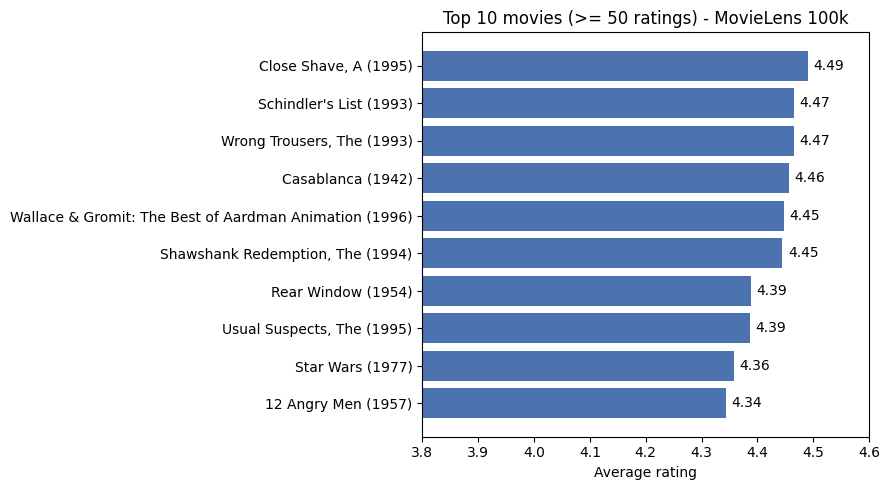

In [24]:
rows = top10_df.collect()
titles = [r["title"] for r in rows][::-1]
scores = [r["avg_rating"] for r in rows][::-1]
plt.figure(figsize=(9,5))
plt.barh(titles, scores, color="#4C72B0")
plt.xlabel("Average rating"); plt.xlim(3.8,4.6)
plt.title(f"Top 10 movies (>= {MIN_RATINGS} ratings) - MovieLens 100k")
for i,v in enumerate(scores): plt.text(v+0.01,i,f"{v:.2f}",va="center")
plt.tight_layout(); plt.show()

## Task (iii) — Power users (>=50 ratings) & favourite genre (Requirements 6 & 9)

In [25]:
power_users = (ratings_clean.groupBy("user_id").count()
               .withColumnRenamed("count","num_ratings")
               .filter(F.col("num_ratings")>=50))
print("Power users:", power_users.count())

genre_struct = F.array(*[F.when(F.col(g)==1, F.lit(g)) for g in GENRE_COLUMNS])
item_genres = (items_clean.select("item_id", F.explode(genre_struct).alias("genre"))
               .filter(F.col("genre").isNotNull()))

user_genre_counts = (ratings_clean.join(power_users,"user_id")
    .join(item_genres,"item_id")
    .groupBy("user_id","genre").agg(F.count("*").alias("genre_count")))

w_fav = Window.partitionBy("user_id").orderBy(F.col("genre_count").desc(), F.col("genre").asc())
favourite_genre = (user_genre_counts.withColumn("rk", F.row_number().over(w_fav))
    .filter(F.col("rk")==1)
    .select("user_id", F.col("genre").alias("favourite_genre"), "genre_count"))

power_user_fav = (favourite_genre.join(power_users,"user_id")
                  .orderBy(F.col("num_ratings").desc()))
power_user_fav.show(10, truncate=False)

Power users: 568
+-------+---------------+-----------+-----------+
|user_id|favourite_genre|genre_count|num_ratings|
+-------+---------------+-----------+-----------+
|405    |Drama          |309        |737        |
|655    |Drama          |410        |685        |
|13     |Drama          |218        |636        |
|450    |Drama          |237        |540        |
|276    |Drama          |168        |518        |
|416    |Drama          |212        |493        |
|537    |Drama          |251        |490        |
|303    |Comedy         |184        |484        |
|234    |Drama          |213        |480        |
|393    |Comedy         |191        |448        |
+-------+---------------+-----------+-----------+
only showing top 10 rows



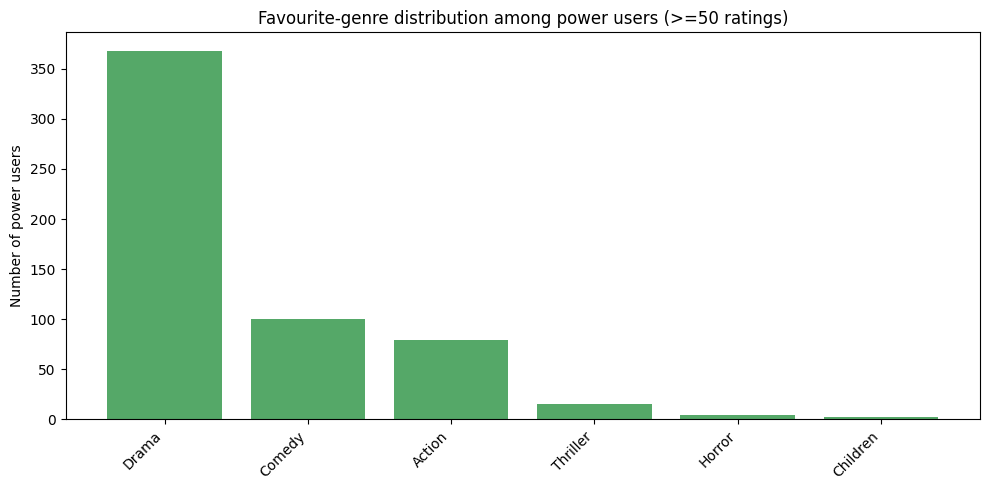

In [26]:
dist = (favourite_genre.groupBy("favourite_genre").count()
        .orderBy(F.col("count").desc()).collect())
plt.figure(figsize=(10,5))
plt.bar([r["favourite_genre"] for r in dist], [r["count"] for r in dist], color="#55A868")
plt.ylabel("Number of power users"); plt.xticks(rotation=45, ha="right")
plt.title("Favourite-genre distribution among power users (>=50 ratings)")
plt.tight_layout(); plt.show()

## Task (iv) — Users younger than 20 (Requirement 6)

In [27]:
young_users = spark.sql('''
    SELECT user_id, age, gender, occupation, zip_code
    FROM users WHERE age < 20 ORDER BY age, user_id
''')
print("Users < 20:", young_users.count())
young_users.show(10, truncate=False)

Users < 20: 77
+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|30     |7  |M     |student   |55436   |
|471    |10 |M     |student   |77459   |
|289    |11 |M     |none      |94619   |
|142    |13 |M     |other     |48118   |
|609    |13 |F     |student   |55106   |
|628    |13 |M     |none      |94306   |
|674    |13 |F     |student   |55337   |
|880    |13 |M     |student   |83702   |
|206    |14 |F     |student   |53115   |
|813    |14 |F     |student   |02136   |
+-------+---+------+----------+--------+
only showing top 10 rows



## Task (v) — Scientists aged 30-40 inclusive (Requirement 6)

In [28]:
scientists_30_40 = spark.sql('''
    SELECT user_id, age, gender, occupation, zip_code
    FROM users WHERE occupation='scientist' AND age BETWEEN 30 AND 40
    ORDER BY age, user_id
''')
print("Scientists 30-40:", scientists_30_40.count())
scientists_30_40.show(truncate=False)

Scientists 30-40: 16
+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|538    |31 |M     |scientist |21010   |
|730    |31 |F     |scientist |32114   |
|554    |32 |M     |scientist |62901   |
|183    |33 |M     |scientist |27708   |
|272    |33 |M     |scientist |53706   |
|543    |33 |M     |scientist |95123   |
|874    |36 |M     |scientist |37076   |
|337    |37 |M     |scientist |10522   |
|40     |38 |M     |scientist |27514   |
|430    |38 |M     |scientist |98199   |
|71     |39 |M     |scientist |98034   |
|74     |39 |M     |scientist |T8H1N   |
|107    |39 |M     |scientist |60466   |
|643    |39 |M     |scientist |55122   |
|309    |40 |M     |scientist |70802   |
|918    |40 |M     |scientist |70116   |
+-------+---+------+----------+--------+



## 6. Cassandra keyspace & tables (Requirement 7)
A query-first schema is used (the design rationale is given in the cluster notebook). The
DDL is run with the native `cassandra-driver`, since the bundled `cqlsh` is broken on
Colab's newer Python.

In [29]:
# Create the keyspace + tables with the native driver (no cqlsh).
from cassandra.cluster import Cluster
session = Cluster(['127.0.0.1'], port=9042).connect()

ddl = [
    "CREATE KEYSPACE IF NOT EXISTS movielens WITH replication = {'class':'SimpleStrategy','replication_factor':1}",
    "CREATE TABLE IF NOT EXISTS movielens.movie_avg_ratings (item_id int PRIMARY KEY, title text, avg_rating double, num_ratings int)",
    "CREATE TABLE IF NOT EXISTS movielens.top_movies (bucket text, avg_rating double, item_id int, title text, num_ratings int, "
    "PRIMARY KEY ((bucket), avg_rating, item_id)) WITH CLUSTERING ORDER BY (avg_rating DESC, item_id ASC)",
    "CREATE TABLE IF NOT EXISTS movielens.user_favourite_genre (user_id int PRIMARY KEY, favourite_genre text, genre_count int, num_ratings int)",
    "CREATE TABLE IF NOT EXISTS movielens.users_by_occ_age (occupation text, age int, user_id int, gender text, zip_code text, "
    "PRIMARY KEY ((occupation), age, user_id)) WITH CLUSTERING ORDER BY (age ASC, user_id ASC)",
]
for stmt in ddl:
    session.execute(stmt)

print("Keyspace + tables created:")
for row in session.execute("SELECT table_name FROM system_schema.tables WHERE keyspace_name='movielens'"):
    print("  -", row.table_name)

Keyspace + tables created:
  - movie_avg_ratings
  - top_movies
  - user_favourite_genre
  - users_by_occ_age


## 7. Write DataFrames into Cassandra (Requirement 7)

In [30]:
def write_cass(df, table, keyspace="movielens"):
    (df.write.format("org.apache.spark.sql.cassandra")
        .options(keyspace=keyspace, table=table).mode("append").save())
    print(f"  -> wrote {df.count():>6} rows into {keyspace}.{table}")

write_cass(avg_rating_df.select("item_id","title","avg_rating","num_ratings"), "movie_avg_ratings")
top_for_cass = top10_df.withColumn("bucket", F.lit("all")).select(
    "bucket","avg_rating","item_id","title","num_ratings")
write_cass(top_for_cass, "top_movies")
write_cass(power_user_fav.select("user_id","favourite_genre","genre_count","num_ratings"),
           "user_favourite_genre")
write_cass(users_clean.select("occupation","age","user_id","gender","zip_code"),
           "users_by_occ_age")

  -> wrote   1682 rows into movielens.movie_avg_ratings
  -> wrote     10 rows into movielens.top_movies
  -> wrote    568 rows into movielens.user_favourite_genre
  -> wrote    943 rows into movielens.users_by_occ_age


## 8. Read back from Cassandra to validate (Requirement 8)

In [31]:
def read_cass(table, keyspace="movielens"):
    return (spark.read.format("org.apache.spark.sql.cassandra")
              .options(keyspace=keyspace, table=table).load())

avg_back   = read_cass("movie_avg_ratings")
top_back   = read_cass("top_movies")
users_back = read_cass("users_by_occ_age")
print("movie_avg_ratings rows:", avg_back.count())
print("top_movies        rows:", top_back.count())

print("=== Top 10 read back (already DESC-ordered) ===")
top_back.orderBy(F.col("avg_rating").desc()).select("avg_rating","title","num_ratings").show(10, truncate=False)

print("=== Task (v) re-derived from Cassandra ===")
(users_back.filter((F.col("occupation")=="scientist") & F.col("age").between(30,40))
    .select("user_id","age","gender","zip_code").orderBy("age","user_id").show(truncate=False))

assert avg_back.count() == avg_rating_df.count(), "row-count mismatch!"
print("\nValidation passed: Cassandra round-trip matches source.")

movie_avg_ratings rows: 1682
top_movies        rows: 10
=== Top 10 read back (already DESC-ordered) ===
+----------+------------------------------------------------------+-----------+
|avg_rating|title                                                 |num_ratings|
+----------+------------------------------------------------------+-----------+
|4.491     |Close Shave, A (1995)                                 |112        |
|4.466     |Wrong Trousers, The (1993)                            |118        |
|4.466     |Schindler's List (1993)                               |298        |
|4.457     |Casablanca (1942)                                     |243        |
|4.448     |Wallace & Gromit: The Best of Aardman Animation (1996)|67         |
|4.445     |Shawshank Redemption, The (1994)                      |283        |
|4.388     |Rear Window (1954)                                    |209        |
|4.386     |Usual Suspects, The (1995)                            |267        |
|4.358     |Star

---
# Optional Extension A — MongoDB (to be run only if desired)
MongoDB 7.0 is installed inside the Colab VM by the next cell. It is **not required** for
the core pipeline and may be skipped if only the HDFS + Spark + Cassandra deliverable is
needed.

In [32]:
%%bash
# --- OPTIONAL: install & start MongoDB community server in Colab ---
wget -qO /usr/share/keyrings/mongodb.asc https://www.mongodb.org/static/pgp/server-7.0.asc
echo "deb [signed-by=/usr/share/keyrings/mongodb.asc] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse" \
  > /etc/apt/sources.list.d/mongodb-org-7.0.list
apt-get -qq update > /dev/null
apt-get -qq install -y mongodb-org > /dev/null
mkdir -p /data/db
mongod --fork --logpath /content/mongod.log
echo "MongoDB started:"; tail -1 /content/mongod.log

about to fork child process, waiting until server is ready for connections.
forked process: 8384
child process started successfully, parent exiting
MongoDB started:
{"t":{"$date":"2026-06-10T03:17:04.926+00:00"},"s":"I",  "c":"CONTROL",  "id":8423403, "ctx":"initandlisten","msg":"mongod startup complete","attr":{"Summary of time elapsed":{"Startup from clean shutdown?":true,"Statistics":{"Transport layer setup":"0 ms","Run initial syncer crash recovery":"0 ms","Create storage engine lock file in the data directory":"0 ms","Get metadata describing storage engine":"0 ms","Create storage engine":"750 ms","Write current PID to file":"0 ms","Write a new metadata for storage engine":"10 ms","Initialize FCV before rebuilding indexes":"0 ms","Drop abandoned idents and get back indexes that need to be rebuilt or builds that need to be restarted":"0 ms","Rebuild indexes for collections":"0 ms","Load cluster parameters from disk for a standalone":"0 ms","Build user and roles graph":"0 ms","Set up

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [33]:
MONGO_URI = "mongodb://127.0.0.1:27017"; MONGO_DB = "movielens"

def write_mongo(df, coll):
    (df.write.format("mongodb").option("connection.uri", MONGO_URI)
        .option("database", MONGO_DB).option("collection", coll)
        .mode("overwrite").save())
    print(f"  -> wrote {df.count()} docs into mongo::{coll}")

def read_mongo(coll):
    return (spark.read.format("mongodb").option("connection.uri", MONGO_URI)
            .option("database", MONGO_DB).option("collection", coll).load())

write_mongo(avg_rating_df.select("item_id","title","avg_rating","num_ratings"), "movie_avg_ratings")
write_mongo(top10_df, "top_movies")
write_mongo(scientists_30_40, "scientists_30_40")
write_mongo(young_users, "users_under_20")

print("=== Top 10 read back from MongoDB ===")
read_mongo("top_movies").orderBy(F.col("avg_rating").desc()).select("avg_rating","title","num_ratings").show(10, truncate=False)
print("scientists_30_40 docs:", read_mongo("scientists_30_40").count())

  -> wrote 1682 docs into mongo::movie_avg_ratings
  -> wrote 10 docs into mongo::top_movies
  -> wrote 16 docs into mongo::scientists_30_40
  -> wrote 77 docs into mongo::users_under_20
=== Top 10 read back from MongoDB ===
+----------+------------------------------------------------------+-----------+
|avg_rating|title                                                 |num_ratings|
+----------+------------------------------------------------------+-----------+
|4.491     |Close Shave, A (1995)                                 |112        |
|4.466     |Schindler's List (1993)                               |298        |
|4.466     |Wrong Trousers, The (1993)                            |118        |
|4.457     |Casablanca (1942)                                     |243        |
|4.448     |Wallace & Gromit: The Best of Aardman Animation (1996)|67         |
|4.445     |Shawshank Redemption, The (1994)                      |283        |
|4.388     |Rear Window (1954)                         

---
# Optional Extension B — HBase *(documentation only — not run on Colab)*
HDFS, ZooKeeper and a Thrift gateway are required by HBase, which is impractical to stand
up inside a single Colab VM. The code below is the **cluster** version (the logic is
identical to the Cassandra writes, keyed by a single row key). **It must not be run on
Colab** — it is included only so that the extension is documented, and should be run only
on the full cluster from `movielens_pipeline.ipynb`.

```python
import happybase
# 'movie_avg_ratings','cf' must be created in the hbase shell first, then:
conn = happybase.Connection("127.0.0.1")          # `hbase thrift start` is required
tbl  = conn.table("movie_avg_ratings")
with tbl.batch(batch_size=500) as b:
    for r in avg_rating_df.collect():
        b.put(str(r["item_id"]).encode(),
              {b"cf:title": str(r["title"]).encode(),
               b"cf:avg_rating": str(r["avg_rating"]).encode(),
               b"cf:num_ratings": str(r["num_ratings"]).encode()})
conn.close()
# read-back: tbl.row(b"1")  /  a scan + client-side sort for the top-10
```

---
## Verified results (real MovieLens 100k run)

| Task | Result |
|---|---|
| (i) per-movie averages | All 1,682 rated movies scored; support (ratings per film) is highly uneven |
| (ii) top movie | *A Close Shave (1995)* — 4.491 over 112 ratings (≥50-rating threshold applied) |
| (iii) power users | 568 users with ≥50 ratings; favourite genres Drama 368 / Comedy 100 / Action 80 / Thriller 15 / Horror 4 / Children 2 |
| (iv) under-20 users | 77 (youngest is 7) |
| (v) scientists 30–40 | 16 (all male in this sample) |

## Discussion & Limitations

**Cross-cutting findings.** (1) Popularity is heavily skewed — rating counts follow a long tail, so
quality measures must be weighted by support (Tasks i–ii). (2) Observed genre preference is
confounded by catalogue supply — Drama's dominance among power users mirrors how many Drama films
exist to be rated, not an unbiased taste signal (Task iii). (3) Demographic segments are small and
self-reported — the under-20 and scientist cohorts are thin and skewed (Tasks iv–v).

**Methodological choices.** A ≥50-rating support threshold was adopted for ranking (a transparent
bias–variance trade-off); genre flags were exploded so multi-genre films count toward every genre;
deduplication kept the most recent rating per (user, film); and ties were broken deterministically
for reproducibility.

**Threats to validity.** MovieLens 100k is a filtered, self-reported, late-1990s Western-cinema
sample; the results are internally valid for this dataset but should not be generalised.

**Storage-design takeaway.** Cassandra was modelled query-first (pre-sorted, partition-aligned) and
serves rankings/slices with no `ALLOW FILTERING`; HBase needs a scan + client-side sort for the
same ranking; MongoDB stores heterogeneous results most ergonomically but trades scan performance.
The same analytics on three stores makes the "model around the read pattern" principle concrete.

---
## Conclusion
On Colab the full **HDFS → Spark RDD → DataFrame → Cassandra → read-back** loop is run
end-to-end: the three files are genuinely loaded into a single-node HDFS (Requirement 2),
are processed in Spark, are persisted to Cassandra, and are validated on read-back, with
**MongoDB** provided as an optional extra. HBase is documented but is left to the
real-cluster notebook. The analytical code is identical to `movielens_pipeline.ipynb`;
only the in-VM service setup is changed.